nyquist and bode plots

Candidates with 'EIS' in the path: 12
Example file: //Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_IX/EIS_state_IX_25C02.txt
Selected cycles: [np.float64(1.0), np.float64(126.0), np.float64(250.0)]


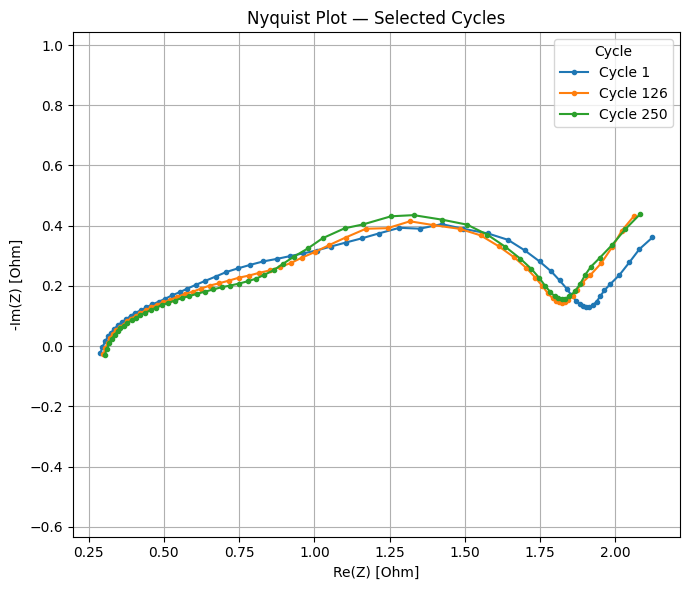

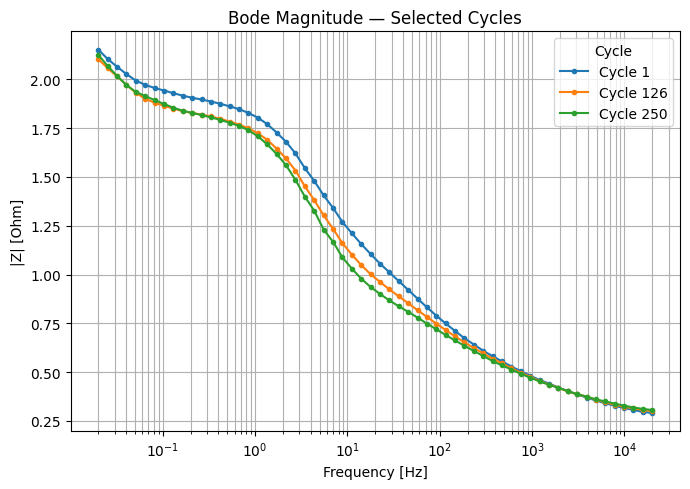

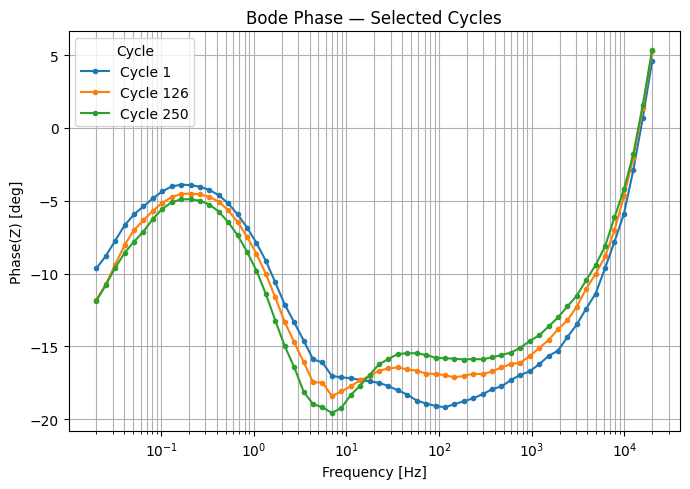

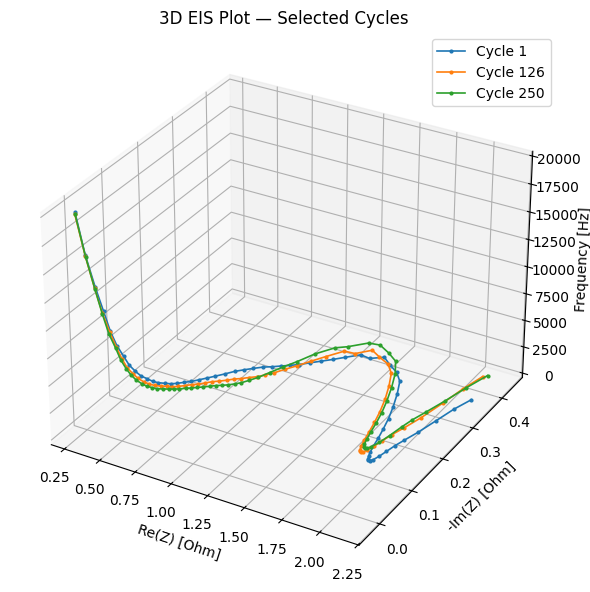

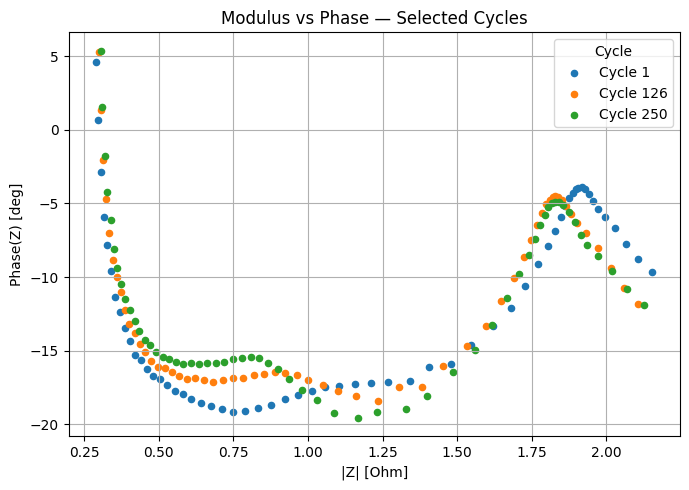

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Find EIS-related .txt files
candidates = [str(p) for p in Path("//Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_IX").rglob("*.txt") if "EIS" in str(p)]
print("Candidates with 'EIS' in the path:", len(candidates))
print("Example file:", candidates[0])  # First EIS file found

# Step 2: Load the first file
df = pd.read_csv(candidates[0], sep='\t', engine='python')

# Clean up column names by removing leading/trailing spaces
df.columns = [col.strip() for col in df.columns]

# Ensure selected columns are numeric (convert strings or missing values to NaN)
numeric_cols = ['time/s', 'cycle number', 'freq/Hz', 'Re(Z)/Ohm', '-Im(Z)/Ohm', '|Z|/Ohm', 'Phase(Z)/deg']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Identify unique cycles in the data
cycles = df['cycle number'].dropna().unique()

# Sort cycles
cycles = np.sort(cycles)

# Pick 3 cycles: first, middle, last
if len(cycles) > 2:
    selected_cycles = [cycles[0], cycles[len(cycles)//2], cycles[-1]]
else:
    selected_cycles = cycles  # if less than 3 available

print("Selected cycles:", selected_cycles)

        

plt.figure(figsize=(7, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    plt.plot(
        df_cycle['Re(Z)/Ohm'],
        df_cycle['-Im(Z)/Ohm'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('Re(Z) [Ohm]')
plt.ylabel('-Im(Z) [Ohm]')
plt.title('Nyquist Plot — Selected Cycles')
plt.grid(True)
plt.axis('equal')
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()

# Bode Magnitude Plot: Frequency vs |Z|
plt.figure(figsize=(7, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    plt.semilogx(
        df_cycle['freq/Hz'],
        df_cycle['|Z|/Ohm'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('Frequency [Hz]')
plt.ylabel('|Z| [Ohm]')
plt.title('Bode Magnitude — Selected Cycles')
plt.grid(True, which='both')
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()

# Bode Phase Plot: Frequency vs Phase
plt.figure(figsize=(7, 5))

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    plt.semilogx(
        df_cycle['freq/Hz'],
        df_cycle['Phase(Z)/deg'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase(Z) [deg]')
plt.title('Bode Phase — Selected Cycles')
plt.grid(True, which='both')
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()

# 3D Plot: Re(Z), -Im(Z), Frequency
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    ax.plot(
        df_cycle['Re(Z)/Ohm'],
        df_cycle['-Im(Z)/Ohm'],
        df_cycle['freq/Hz'],
        marker='o',
        markersize=2,
        linewidth=1.2,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

ax.set_xlabel('Re(Z) [Ohm]')
ax.set_ylabel('-Im(Z) [Ohm]')
ax.set_zlabel('Frequency [Hz]')
ax.set_title('3D EIS Plot — Selected Cycles')
ax.legend()
plt.tight_layout()
plt.show()

# Modulus vs Phase Plot: Color-coded by Frequency
plt.figure(figsize=(7, 5))

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle]

    plt.scatter(
        df_cycle['|Z|/Ohm'],
        df_cycle['Phase(Z)/deg'],
        s=20,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('|Z| [Ohm]')
plt.ylabel('Phase(Z) [deg]')
plt.title('Modulus vs Phase — Selected Cycles')
plt.grid(True)
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()


   

In [ ]:
plots for all cycles

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Find EIS-related .txt files
candidates = [str(p) for p in Path("//Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_IX").rglob("*.txt") if "EIS" in str(p)]
print("Candidates with 'EIS' in the path:", len(candidates))
print("Example file:", candidates[0])  # First EIS file found

# Step 2: Load the first file
df = pd.read_csv(candidates[0], sep='\t', engine='python')

# Clean up column names by removing leading/trailing spaces
df.columns = [col.strip() for col in df.columns]

# Ensure selected columns are numeric (convert strings or missing values to NaN)
numeric_cols = ['time/s', 'cycle number', 'freq/Hz', 'Re(Z)/Ohm', '-Im(Z)/Ohm', '|Z|/Ohm', 'Phase(Z)/deg']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Identify unique cycles in the data
cycles = df['cycle number'].dropna().unique()
        

# Generate plots for each individual cycle
for cycle in cycles:
    # Filter and sort data for the current cycle by descending frequency
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    # Nyquist Plot: Re(Z) vs -Im(Z)
    plt.figure(figsize=(6, 5))
    plt.plot(df_cycle['Re(Z)/Ohm'], df_cycle['-Im(Z)/Ohm'], marker='o')
    plt.xlabel('Re(Z) [Ohm]')
    plt.ylabel('-Im(Z) [Ohm]')
    plt.title(f'Nyquist Plot - Cycle {int(cycle)}')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

    '''# Bode Magnitude Plot: Frequency vs |Z|
    plt.figure(figsize=(6, 5))
    plt.semilogx(df_cycle['freq/Hz'], df_cycle['|Z|/Ohm'], marker='o')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('|Z| [Ohm]')
    plt.title(f'Bode Magnitude Plot - Cycle {int(cycle)}')
    plt.grid(True)
    plt.show()

    # Bode Phase Plot: Frequency vs Phase
    plt.figure(figsize=(6, 5))
    plt.semilogx(df_cycle['freq/Hz'], df_cycle['Phase(Z)/deg'], marker='o', color='r')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Phase(Z) [deg]')
    plt.title(f'Bode Phase Plot - Cycle {int(cycle)}')
    plt.grid(True)
    plt.show()

    # 3D Plot: Re(Z), -Im(Z), Frequency
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(df_cycle['Re(Z)/Ohm'], df_cycle['-Im(Z)/Ohm'], df_cycle['freq/Hz'], marker='o')
    ax.set_xlabel('Re(Z) [Ohm]')
    ax.set_ylabel('-Im(Z) [Ohm]')
    ax.set_zlabel('Frequency [Hz]')
    ax.set_title(f'3D EIS Plot - Cycle {int(cycle)}')
    plt.show()

    # Modulus vs Phase Plot: Color-coded by Frequency
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(df_cycle['|Z|/Ohm'], df_cycle['Phase(Z)/deg'], c=df_cycle['freq/Hz'], cmap='viridis')
    plt.colorbar(scatter, label='Frequency [Hz]')
    plt.xlabel('|Z| [Ohm]')
    plt.ylabel('Phase(Z) [deg]')
    plt.title(f'Modulus vs Phase - Cycle {int(cycle)}')
    plt.grid(True)
    plt.show()'''


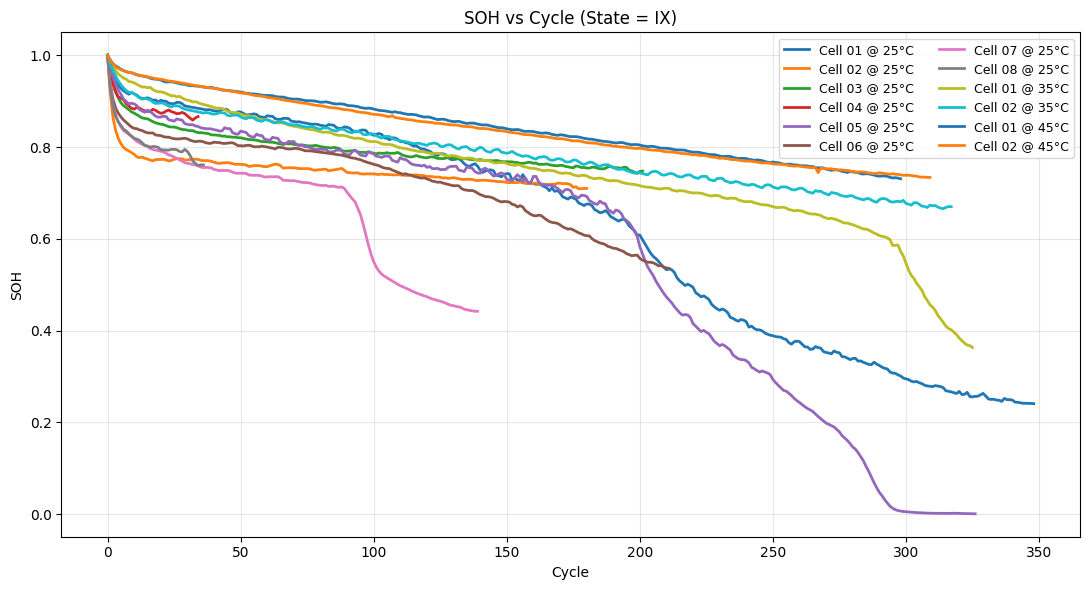

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- load ----
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')  # <- change path if needed

# ---- select state (use "IX" because your file shows state as roman numeral) ----
STATE = "IX"   # if you want state 9 but stored as IX in data
d = df[df["state"] == STATE].copy()

# ---- plot ----
plt.figure(figsize=(11, 6))

# one color per temperature (matplotlib will pick default distinct colors)
temps = sorted(d["T_C"].unique())

for T in temps:
    dT = d[d["T_C"] == T]
    for cell_id, g in dT.groupby("cell"):
        g = g.sort_values("cycle")
        plt.plot(g["cycle"], g["SOH"], linewidth=2, label=f"Cell {int(cell_id):02d} @ {int(T)}°C")

plt.title(f"SOH vs Cycle (State = {STATE})")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.grid(True, alpha=0.3)

# Legend can get big; this keeps it readable
plt.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


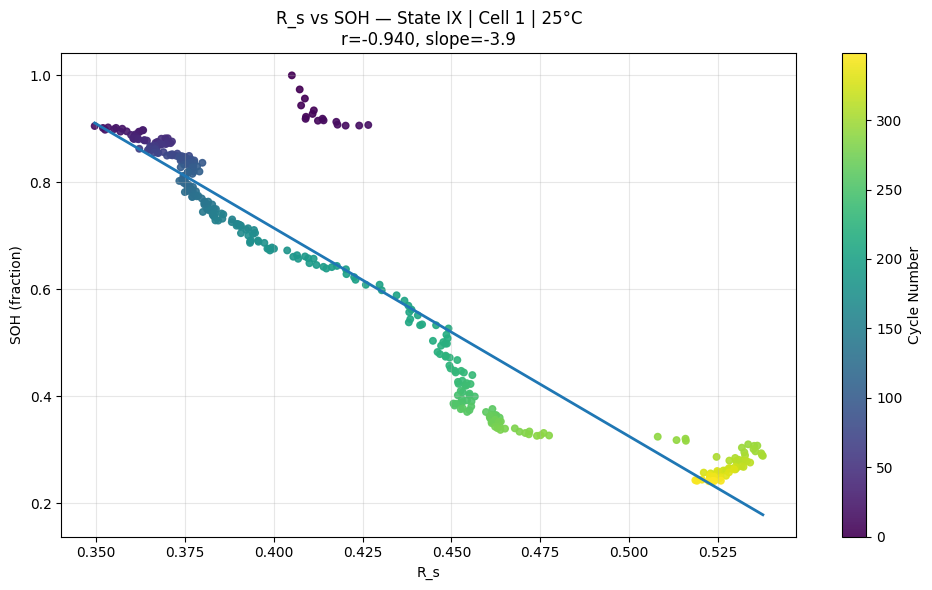

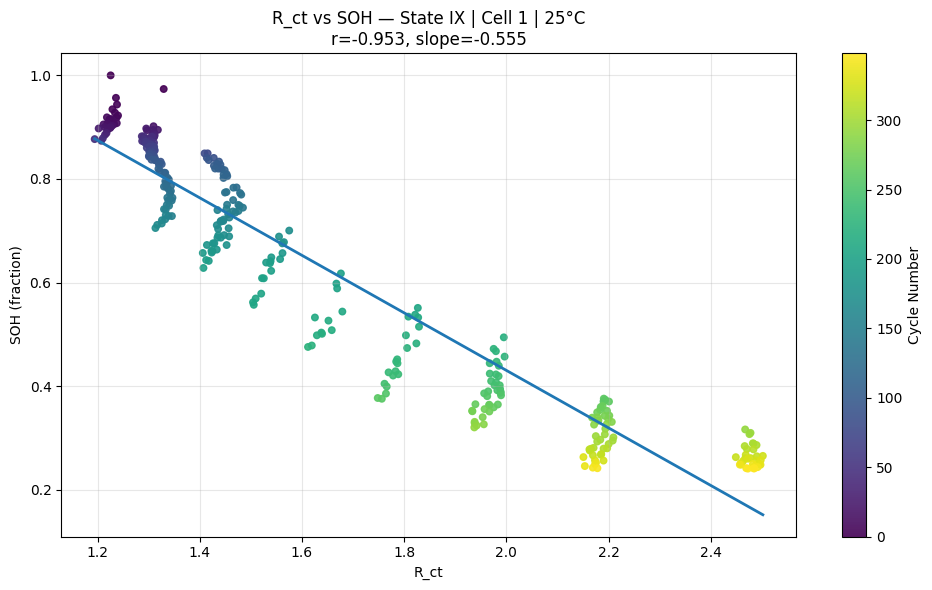

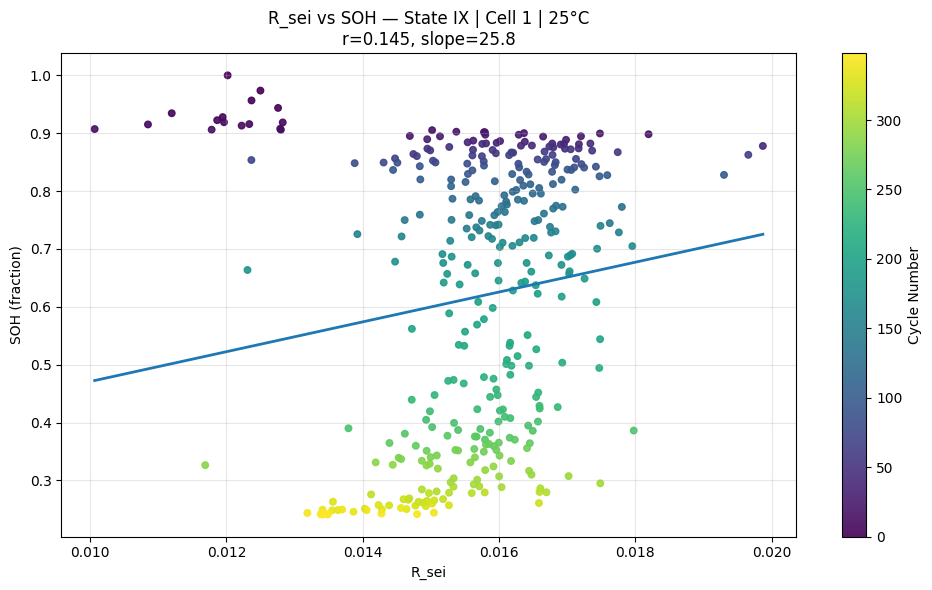

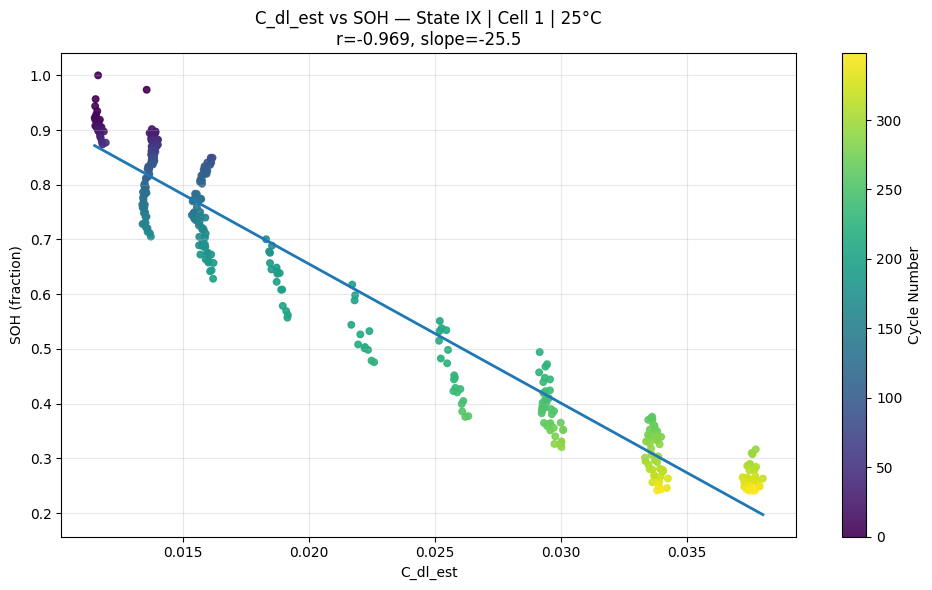

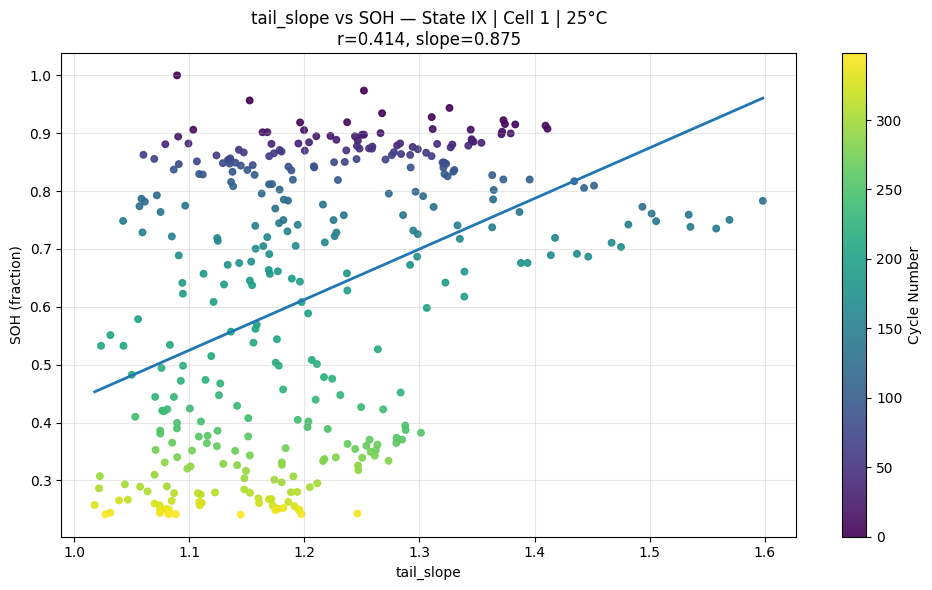

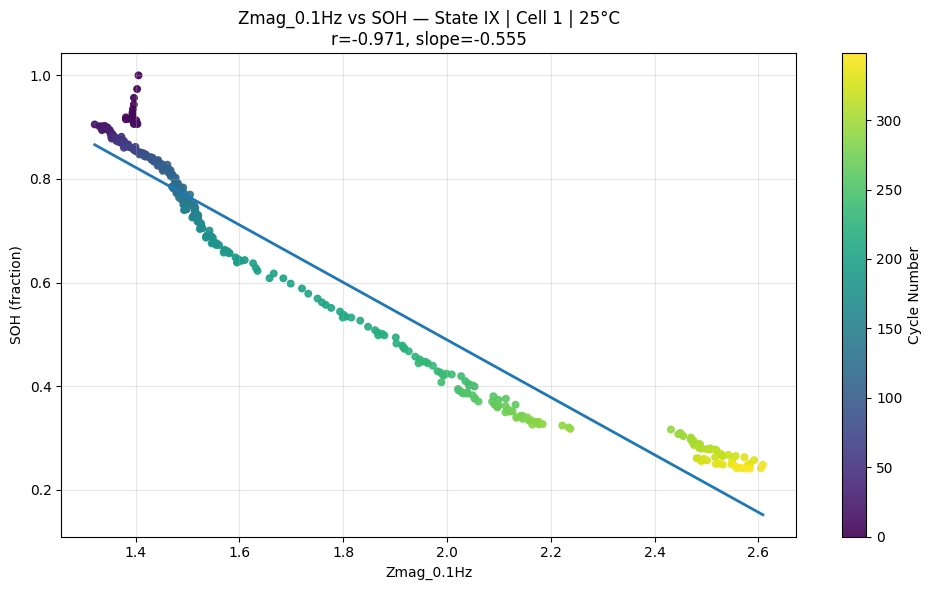

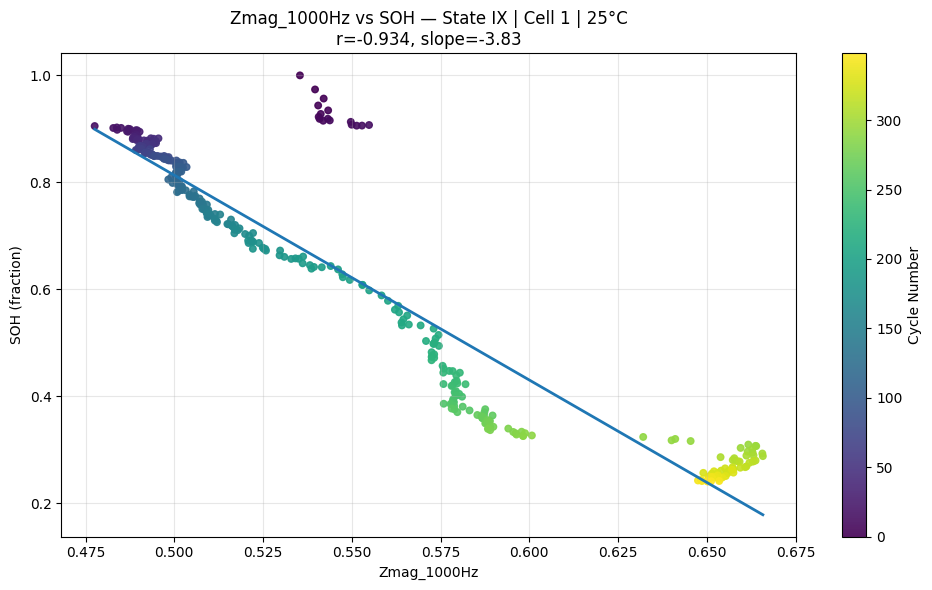

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#df = pd.read_csv("final_7features_state_IX.csv")

STATE = "IX"
CELL_ID = 1
TEMP_C = 25  # set None to ignore

features = [
    "R_s","R_ct","R_sei","C_dl_est","tail_slope","Zmag_0.1Hz","Zmag_1000Hz"
]

d = df[df["state"].astype(str) == str(STATE)].copy()
d = d[d["cell"] == CELL_ID].copy()
if TEMP_C is not None:
    d = d[d["T_C"] == TEMP_C].copy()

d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["cycle","SOH"] + features).sort_values("cycle")

cycles = d["cycle"].to_numpy()
norm = plt.Normalize(vmin=np.nanmin(cycles), vmax=np.nanmax(cycles))
cmap = plt.cm.viridis

for feat in features:
    x = pd.to_numeric(d[feat], errors="coerce").to_numpy()
    y = pd.to_numeric(d["SOH"], errors="coerce").to_numpy()
    c = pd.to_numeric(d["cycle"], errors="coerce").to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    x, y, c = x[mask], y[mask], c[mask]

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, c=c, cmap=cmap, norm=norm, s=22, alpha=0.9)

    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        r = np.corrcoef(x, y)[0, 1]
        xx = np.linspace(np.min(x), np.max(x), 200)
        plt.plot(xx, slope * xx + intercept, linewidth=2)
        plt.title(f"{feat} vs SOH — State {STATE} | Cell {CELL_ID}" + (f" | {TEMP_C}°C" if TEMP_C is not None else "") + f"\nr={r:.3f}, slope={slope:.3g}")
    else:
        plt.title(f"{feat} vs SOH — State {STATE} | Cell {CELL_ID}")

    plt.xlabel(feat)
    plt.ylabel("SOH (fraction)")
    plt.grid(True, alpha=0.3)
    cbar = plt.colorbar()
    cbar.set_label("Cycle Number")
    plt.tight_layout()
    plt.show()
